WEEK 4 — PYTHON BUSINESS INTELLIGENCE ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
df=pd.read_csv("../../data/PS_20174392719_1491204439457_log.csv")
print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully
Rows: 6362620
Columns: 11


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
df.describe(include="all")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.00",6362620,"6,362,620.00",6362620,"6,362,620.00","6,362,620.00",6362620,"6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00"
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C2098525306,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,243.40,NaN,"179,861.90",NaN,"833,883.10","855,113.67",NaN,"1,100,701.67","1,224,996.40",0.00,0.00
std,142.33,NaN,"603,858.23",NaN,"2,888,242.67","2,924,048.50",NaN,"3,399,180.11","3,674,128.94",0.04,0.00
min,1.00,NaN,0.00,NaN,0.00,0.00,NaN,0.00,0.00,0.00,0.00
25%,156.00,NaN,"13,389.57",NaN,0.00,0.00,NaN,0.00,0.00,0.00,0.00
50%,239.00,NaN,"74,871.94",NaN,"14,208.00",0.00,NaN,"132,705.66","214,661.44",0.00,0.00
75%,335.00,NaN,"208,721.48",NaN,"107,315.18","144,258.41",NaN,"943,036.71","1,111,909.25",0.00,0.00


DATA QUALITY TABLE

In [7]:
data_quality = pd.DataFrame({
    "Quality Check": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Rows",
        "Invalid Transaction Types",
        "Number of Negative Transaction",
        "Number of Zero Transaction"
    ],
    
    "Result": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (~df["type"].isin([
            "CASH-IN",
            "CASH-OUT",
            "PAYMENT",
            "DEBIT",
            "TRANSFER"
        ])).sum(),
        (df["amount"] < 0).sum(),
        (df["amount"] == 0).sum()
    ]
})

data_quality

,Quality Check,Result
0,Number of Rows,6362620
1,Number of Columns,11
2,Missing Values,0
3,Duplicate Rows,0
4,Invalid Transaction Types,3636784
5,Number of Negative Transaction,0
6,Number of Zero Transaction,16


NEGATIVE VALUES IN THE DATASET

In [8]:
other_data_quality = pd.DataFrame({
    "Quality Check": [
        "Negative Transactions in oldbalanceOrg",
        "Negative Transactions in newbalanceOrig",
        "Negative Transactions in oldbalanceDest",
        "Negative Transactions in newbalanceDest",
        "Negative Transaction in isFraud",
        "Negative Transaction in isFlaggedFraud"
    ],
    
    "Result": [
        (df['oldbalanceOrg'] < 0).sum(),
        (df['newbalanceOrig'] < 0).sum(),
        (df['oldbalanceDest'] < 0).sum(),
        (df['newbalanceDest'] < 0).sum(),
        (df['isFraud'] < 0).sum(),
        (df['isFlaggedFraud'] < 0).sum()
   ]
})

other_data_quality

,Quality Check,Result
0,Negative Transactions in oldbalanceOrg,0
1,Negative Transactions in newbalanceOrig,0
2,Negative Transactions in oldbalanceDest,0
3,Negative Transactions in newbalanceDest,0
4,Negative Transaction in isFraud,0
5,Negative Transaction in isFlaggedFraud,0


Check duplicates

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


TRANSACTION PATTERN

In [10]:
print(df["type"].unique())

<StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str


In [11]:
transaction_type_count = df["type"].value_counts()

transaction_type_count

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [12]:
transaction_type_percentage = (
    df["type"].value_counts(normalize=True) * 100
)

transaction_type_percentage

type
CASH_OUT   35.17
PAYMENT    33.81
CASH_IN    21.99
TRANSFER    8.38
DEBIT       0.65
Name: proportion, dtype: float64

Check fraud values

In [13]:
print(df["isFraud"].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [14]:
# Fraud Percentage
fraud_rate = df["isFraud"].mean() * 100

print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 0.1291%


Create time variables

In [15]:
# Create hour
df["hour"] = (df["step"] - 1) % 24

In [16]:
# Create Simulation day
df["day"] = ((df["step"] - 1) // 24) + 1

In [17]:
df[["step", "hour", "day"]].head(30)

,step,hour,day
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1
5,1,0,1
6,1,0,1
7,1,0,1
8,1,0,1
9,1,0,1


TRANSACTION BEHAVIOUR ANALYSIS

In [18]:
#  Most common transaction types
transaction_summary = df.groupby("type").agg(
    transactions=("type", "size"),
    total_amount=("amount", "sum"),
    average_amount=("amount", "mean")
).reset_index()

transaction_summary

,type,transactions,total_amount,average_amount
0,CASH_IN,1399284,"236,367,391,912.46","168,920.24"
1,CASH_OUT,2237500,"394,412,995,224.49","176,273.96"
2,DEBIT,41432,"227,199,221.28","5,483.67"
3,PAYMENT,2151495,"28,093,371,138.37","13,057.60"
4,TRANSFER,532909,"485,291,987,263.17","910,647.01"


In [19]:
transaction_summary["transaction_percentage"] = (
    transaction_summary["transactions"]
    / transaction_summary["transactions"].sum()
    * 100
)

transaction_summary

,type,transactions,total_amount,average_amount,transaction_percentage
0,CASH_IN,1399284,"236,367,391,912.46","168,920.24",21.99
1,CASH_OUT,2237500,"394,412,995,224.49","176,273.96",35.17
2,DEBIT,41432,"227,199,221.28","5,483.67",0.65
3,PAYMENT,2151495,"28,093,371,138.37","13,057.60",33.81
4,TRANSFER,532909,"485,291,987,263.17","910,647.01",8.38


Transaction amount analysis

In [20]:
# Overall statistics
df["amount"].describe()

count    6,362,620.00
mean       179,861.90
std        603,858.23
min              0.00
25%         13,389.57
50%         74,871.94
75%        208,721.48
max     92,445,516.64
Name: amount, dtype: float64

In [21]:
# Average transaction amount by type
average_amount_by_type = (
    df.groupby("type")["amount"]
      .mean()
      .sort_values(ascending=False)
)

average_amount_by_type

type
TRANSFER   910,647.01
CASH_OUT   176,273.96
CASH_IN    168,920.24
PAYMENT     13,057.60
DEBIT        5,483.67
Name: amount, dtype: float64

In [22]:
# Median transaction amount
median_amount_by_type = (
    df.groupby("type")["amount"]
      .median()
      .sort_values(ascending=False)
)

median_amount_by_type

type
TRANSFER   486,308.39
CASH_OUT   147,072.18
CASH_IN    143,427.71
PAYMENT      9,482.19
DEBIT        3,048.99
Name: amount, dtype: float64

Transaction frequency

In [23]:
customer_frequency = (
    df.groupby("nameOrig")
      .size()
      .reset_index(name="transaction_count")
)

customer_frequency.head()

,nameOrig,transaction_count
0,C1000000639,1
1,C1000001337,1
2,C1000001725,1
3,C1000002591,1
4,C1000003372,1


In [24]:
customer_frequency["transaction_count"].describe()

count   6,353,307.00
mean            1.00
std             0.04
min             1.00
25%             1.00
50%             1.00
75%             1.00
max             3.00
Name: transaction_count, dtype: float64

In [25]:
# Transactions per customer
average_transactions_per_customer = (
    customer_frequency["transaction_count"].mean()
)

median_transactions_per_customer = (
    customer_frequency["transaction_count"].median()
)

print(
    "Average transactions per customer:",
    round(average_transactions_per_customer, 2)
)

print(
    "Median transactions per customer:",
    round(median_transactions_per_customer, 2)
)

Average transactions per customer: 1.0
Median transactions per customer: 1.0


Peak transaction hours

In [26]:
# Number of transactions per hour
hourly_transactions = (
    df.groupby("hour")
      .size()
      .reset_index(name="transactions")
)

hourly_transactions

,hour,transactions
0,0,27111
1,1,9018
2,2,2007
3,3,1241
4,4,1641
5,5,3420
6,6,8988
7,7,26915
8,8,283518
9,9,425729


In [27]:
# The Busiest hour
peak_hour = hourly_transactions.loc[
    hourly_transactions["transactions"].idxmax()
]

print("Peak hour:", peak_hour["hour"])
print("Transactions:", peak_hour["transactions"])

Peak hour: 18
Transactions: 647814


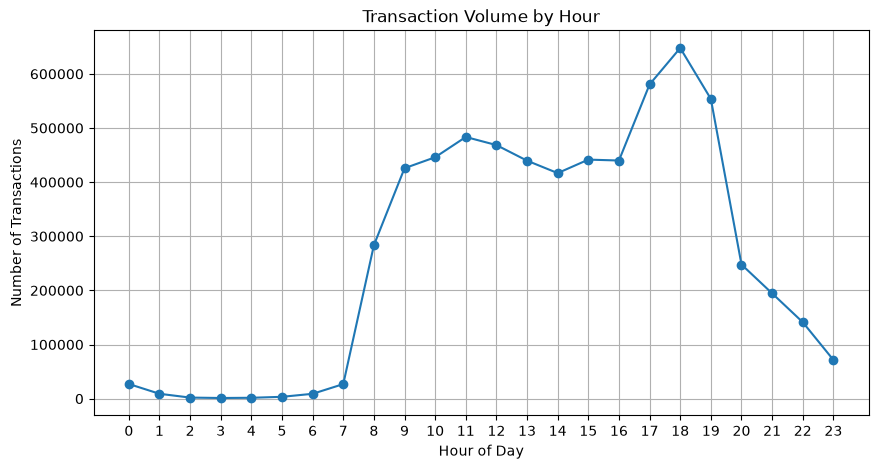

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_transactions["hour"],
    hourly_transactions["transactions"],
    marker="o"
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [29]:
# Transaction activity by day
daily_transactions = (
    df.groupby("day")
      .size()
      .reset_index(name="transactions")
)

daily_transactions.head()

,day,transactions
0,1,574255
1,2,455238
2,3,1070
3,4,28240
4,5,9789


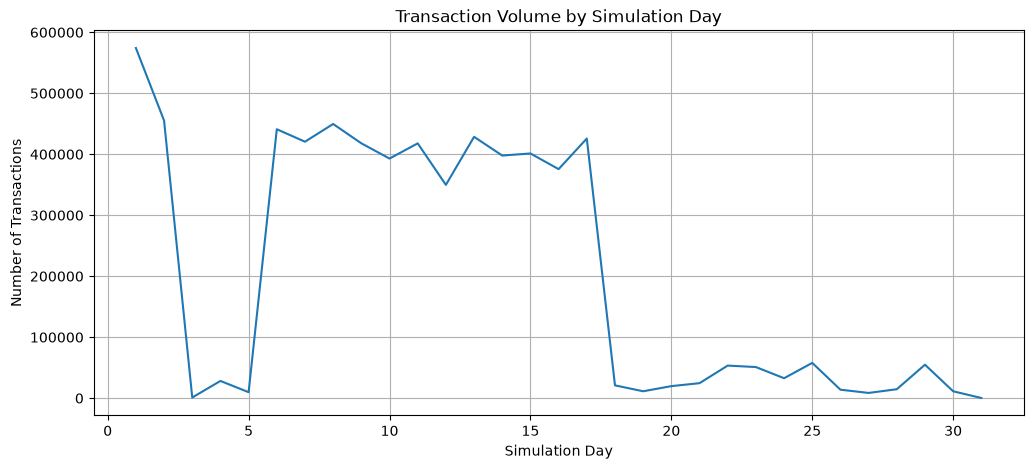

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_transactions["day"],
    daily_transactions["transactions"]
)

plt.title("Transaction Volume by Simulation Day")
plt.xlabel("Simulation Day")
plt.ylabel("Number of Transactions")
plt.grid(True)

plt.show()

In [31]:
# Transaction type by hour
hour_type = pd.crosstab(
    df["hour"],
    df["type"]
)

hour_type.head()

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
hour,,,,,
0,4855,3898,1136,15115,2107
1,2355,1256,449,4292,666
2,417,432,58,752,348
3,230,277,26,473,235
4,302,373,29,678,259


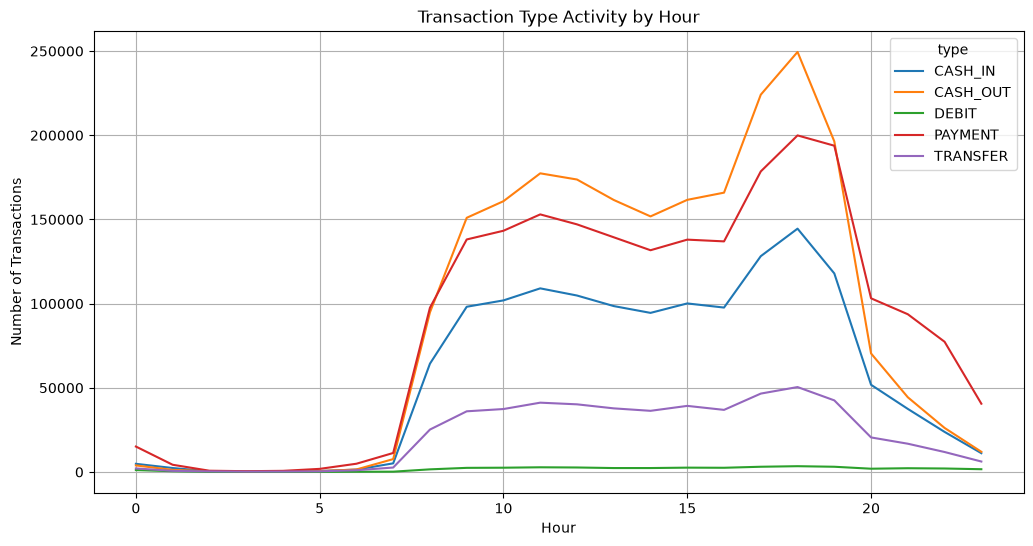

In [32]:
hour_type.plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("Transaction Type Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.grid(True)

plt.show()

* * #### CUSTOMER BALANCE ANALYSIS

In [33]:
# origin balance change
df["origin_balance_change"] = (
    df["newbalanceOrig"] - df["oldbalanceOrg"]
)
df.origin_balance_change

0             -9,839.64
1             -1,864.28
2               -181.00
3               -181.00
4            -11,668.14
               ...     
6362615     -339,682.13
6362616   -6,311,409.28
6362617   -6,311,409.28
6362618     -850,002.52
6362619     -850,002.52
Name: origin_balance_change, Length: 6362620, dtype: float64

In [34]:
# Destination balance change
df["destination_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)
df.destination_balance_change

0                 0.00
1                 0.00
2                 0.00
3           -21,182.00
4                 0.00
              ...     
6362615     339,682.13
6362616           0.00
6362617   6,311,409.27
6362618           0.00
6362619     850,002.52
Name: destination_balance_change, Length: 6362620, dtype: float64

In [35]:
# Analyse by transaction type
balance_summary = df.groupby("type").agg(
    average_old_origin_balance=("oldbalanceOrg", "mean"),
    average_new_origin_balance=("newbalanceOrig", "mean"),
    average_old_destination_balance=("oldbalanceDest", "mean"),
    average_new_destination_balance=("newbalanceDest", "mean")
).reset_index()

balance_summary

,type,average_old_origin_balance,average_new_origin_balance,average_old_destination_balance,average_new_destination_balance
0,CASH_IN,"3,590,463.51","3,759,378.71","1,587,918.80","1,467,105.39"
1,CASH_OUT,"46,023.80","17,474.19","1,497,757.89","1,691,326.07"
2,DEBIT,"68,647.34","65,161.65","1,493,135.77","1,513,003.47"
3,PAYMENT,"68,216.83","61,837.89",0.00,0.00
4,TRANSFER,"54,441.85","10,288.16","2,567,605.72","3,554,566.83"


* * #### BUILD THE CUSTOMER-LEVEL DATASET

In [36]:
customer_df = df.groupby("nameOrig").agg(
    transaction_count=("nameOrig", "size"),
    total_transaction_amount=("amount", "sum"),
    average_transaction_amount=("amount", "mean"),
    maximum_transaction_amount=("amount", "max"),
    average_balance=("oldbalanceOrg", "mean"),
    total_fraud_transactions=("isFraud", "sum")
).reset_index()

customer_df.head()

,nameOrig,transaction_count,total_transaction_amount,average_transaction_amount,maximum_transaction_amount,average_balance,total_fraud_transactions
0,C1000000639,1,"244,486.46","244,486.46","244,486.46","8,946.00",0
1,C1000001337,1,"3,170.28","3,170.28","3,170.28","58,089.00",0
2,C1000001725,1,"8,424.74","8,424.74","8,424.74",783.00,0
3,C1000002591,1,"261,877.19","261,877.19","261,877.19","7,596.00",0
4,C1000003372,1,"20,528.65","20,528.65","20,528.65","2,302,074.12",0


In [37]:
print("Number of customers:", len(customer_df))

Number of customers: 6353307


 CUSTOMER BEHAVIOUR

In [38]:
customer_df[
    [
        "transaction_count",
        "total_transaction_amount",
        "average_transaction_amount",
        "maximum_transaction_amount",
        "average_balance"
    ]
].describe()

,transaction_count,total_transaction_amount,average_transaction_amount,maximum_transaction_amount,average_balance
count,"6,353,307.00","6,353,307.00","6,353,307.00","6,353,307.00","6,353,307.00"
mean,1.00,"180,125.55","179,857.09","180,044.80","833,910.13"
std,0.04,"604,338.12","603,402.02","604,273.43","2,887,155.66"
min,1.00,0.00,0.00,0.00,0.00
25%,1.00,"13,414.88","13,407.53","13,411.94",0.00
50%,1.00,"75,068.47","74,974.39","75,047.69","14,269.83"
75%,1.00,"208,994.84","208,698.21","208,907.98","107,398.00"
max,3.00,"92,445,516.64","92,445,516.64","92,445,516.64","59,585,040.37"


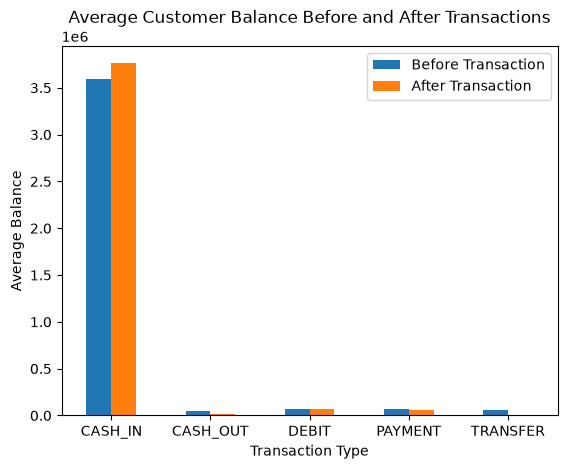

In [39]:
#old vs new customer balance

balance_comparison = (
    df.groupby('type')
    [['oldbalanceOrg', 'newbalanceOrig']]
    .mean()
)

balance_comparison
balance_comparison.plot(kind='bar')

plt.title('Average Customer Balance Before and After Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Average Balance')
plt.xticks(rotation=0)
plt.legend(['Before Transaction', 'After Transaction'])
plt.show()

In [40]:
# CUSTOMER BEHAVIOUR BY TRANSACTION TYPE
customer_behavior_summary = (
    df.groupby('type')
    .agg(
        transactions=('type', 'size'),
        total_value=('amount', 'sum'),
        average_value=('amount', 'mean'),
        median_value=('amount', 'median'),
        average_opening_balance=('oldbalanceOrg', 'mean'),
        average_closing_balance=('newbalanceOrig', 'mean')
    )
    .sort_values('transactions', ascending=False)
)

customer_behavior_summary

,transactions,total_value,average_value,median_value,average_opening_balance,average_closing_balance
type,,,,,,
CASH_OUT,2237500,"394,412,995,224.49","176,273.96","147,072.18","46,023.80","17,474.19"
PAYMENT,2151495,"28,093,371,138.37","13,057.60","9,482.19","68,216.83","61,837.89"
CASH_IN,1399284,"236,367,391,912.46","168,920.24","143,427.71","3,590,463.51","3,759,378.71"
TRANSFER,532909,"485,291,987,263.17","910,647.01","486,308.39","54,441.85","10,288.16"
DEBIT,41432,"227,199,221.28","5,483.67","3,048.99","68,647.34","65,161.65"


CUSTOMER PREFERRED TRANSACTION TYPE

In [41]:
customer_type = (
    df.groupby(["nameOrig", "type"])
      .size()
      .reset_index(name="type_count")
)

customer_type.head()

,nameOrig,type,type_count
0,C1000000639,CASH_OUT,1
1,C1000001337,PAYMENT,1
2,C1000001725,PAYMENT,1
3,C1000002591,CASH_IN,1
4,C1000003372,CASH_IN,1


In [42]:
preferred_type = (
    customer_type
    .sort_values(
        ["nameOrig", "type_count"],
        ascending=[True, False]
    )
    .drop_duplicates("nameOrig")
)

preferred_type = preferred_type[
    ["nameOrig", "type"]
].rename(
    columns={"type": "preferred_transaction_type"}
)

preferred_type.head()

,nameOrig,preferred_transaction_type
0,C1000000639,CASH_OUT
1,C1000001337,PAYMENT
2,C1000001725,PAYMENT
3,C1000002591,CASH_IN
4,C1000003372,CASH_IN


In [43]:
# Merge it into the customer dataset
customer_df = customer_df.merge(
    preferred_type,
    on="nameOrig",
    how="left"
)

customer_df.head()

,nameOrig,transaction_count,total_transaction_amount,average_transaction_amount,maximum_transaction_amount,average_balance,total_fraud_transactions,preferred_transaction_type
0,C1000000639,1,"244,486.46","244,486.46","244,486.46","8,946.00",0,CASH_OUT
1,C1000001337,1,"3,170.28","3,170.28","3,170.28","58,089.00",0,PAYMENT
2,C1000001725,1,"8,424.74","8,424.74","8,424.74",783.00,0,PAYMENT
3,C1000002591,1,"261,877.19","261,877.19","261,877.19","7,596.00",0,CASH_IN
4,C1000003372,1,"20,528.65","20,528.65","20,528.65","2,302,074.12",0,CASH_IN


* * #### CUSTOMER SEGMENTATION

In [44]:
# Select segmentation variables
segmentation_features = [
    "transaction_count",
    "average_transaction_amount",
    "total_transaction_amount",
    "average_balance"
]

X = customer_df[segmentation_features].copy()

In [45]:
# Handle extreme values
X_log = np.log1p(X)
X_log.describe()

,transaction_count,average_transaction_amount,total_transaction_amount,average_balance
count,"6,353,307.00","6,353,307.00","6,353,307.00","6,353,307.00"
mean,0.69,10.84,10.84,7.42
std,0.02,1.81,1.81,5.67
min,0.69,0.00,0.00,0.00
25%,0.69,9.50,9.50,0.00
50%,0.69,11.22,11.23,9.57
75%,0.69,12.25,12.25,11.58
max,1.39,18.34,18.34,17.90


In [46]:
# Standardize the variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

In [47]:
# Find a suitable number of clusters
inertia = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [48]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df["cluster"] = kmeans.fit_predict(X_scaled)

Understand each segment

In [49]:
segment_summary = customer_df.groupby("cluster").agg(
    customers=("nameOrig", "count"),
    average_transactions=("transaction_count", "mean"),
    average_transaction_value=("average_transaction_amount", "mean"),
    average_total_value=("total_transaction_amount", "mean"),
    average_balance=("average_balance", "mean"),
    total_fraud_transactions=("total_fraud_transactions", "sum")
).reset_index()

segment_summary

,cluster,customers,average_transactions,average_transaction_value,average_total_value,average_balance,total_fraud_transactions
0,0,2599355,1.00,"247,310.47","247,310.47","1,832,759.02",7486
1,1,2242026,1.00,"9,939.63","9,939.63","234,828.55",674
2,2,1502628,1.00,"316,679.48","316,679.48",16.54,25
3,3,9298,2.00,"183,181.33","366,625.48","815,143.96",28


Preferred transaction type by segment

In [50]:
segment_transaction_type = pd.crosstab(
    customer_df["cluster"],
    customer_df["preferred_transaction_type"],
    normalize="index"
) * 100

segment_transaction_type

preferred_transaction_type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
cluster,,,,,
0,47.26,39.16,0.03,4.83,8.72
1,5.30,8.70,1.80,83.50,0.70
2,3.19,67.74,0.02,9.82,19.24
3,38.86,42.70,0.45,17.24,0.75


In [51]:
# Creating Mapping
cluster_names = {
    0: "Premium Balance Users",
    1: "Everyday Users",
    2: "High-Value Edge Users",
    3: "Active Value Users"
}

customer_df["customer_segment"] = (
    customer_df["cluster"].map(cluster_names)
)

Segment distribution

In [52]:
segment_distribution = (
    customer_df["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "customer_segment",
    "customers"
]

segment_distribution

,customer_segment,customers
0,Premium Balance Users,2599355
1,Everyday Users,2242026
2,High-Value Edge Users,1502628
3,Active Value Users,9298


In [53]:
segment_distribution["percentage"] = (
    segment_distribution["customers"]
    / segment_distribution["customers"].sum()
    * 100
)

segment_distribution

,customer_segment,customers,percentage
0,Premium Balance Users,2599355,40.91
1,Everyday Users,2242026,35.29
2,High-Value Edge Users,1502628,23.65
3,Active Value Users,9298,0.15


Operational performance

In [55]:
# Peak hour
peak_hour = (
    df.groupby("hour")
      .size()
      .sort_values(ascending=False)
)

print(peak_hour.head(5))

hour
18    647814
17    580509
19    553728
11    483418
12    468474
dtype: int64


In [56]:
# Busiest days
peak_days = (
    df.groupby("day")
      .size()
      .sort_values(ascending=False)
)

print(peak_days.head(10))

day
1     574255
2     455238
8     449637
6     441005
13    428583
17    425766
7     420583
9     417919
11    417859
15    401282
dtype: int64


Fraud analysis

In [57]:
fraud_summary = df.groupby("type").agg(
    transactions=("type", "size"),
    fraud_transactions=("isFraud", "sum"),
    total_amount=("amount", "sum")
).reset_index()
fraud_summary

,type,transactions,fraud_transactions,total_amount
0,CASH_IN,1399284,0,"236,367,391,912.46"
1,CASH_OUT,2237500,4116,"394,412,995,224.49"
2,DEBIT,41432,0,"227,199,221.28"
3,PAYMENT,2151495,0,"28,093,371,138.37"
4,TRANSFER,532909,4097,"485,291,987,263.17"


In [58]:
# Fraud Amount
fraud_amount = df.loc[
    df["isFraud"] == 1,
    "amount"
].sum()

print(f"Total fraud amount: {fraud_amount:,.2f}")

Total fraud amount: 12,056,415,427.84


In [59]:
executive_kpis = {
    "Total Transactions": len(df),
    "Total Transaction Value": df["amount"].sum(),
    "Average Transaction Value": df["amount"].mean(),
    "Total Customers": df["nameOrig"].nunique(),
    "Fraud Transactions": df["isFraud"].sum(),
    "Fraud Rate": df["isFraud"].mean() * 100,
    "Fraud Amount": df.loc[df["isFraud"] == 1, "amount"].sum(),
    "Peak Transaction Hour": int(df["hour"].value_counts().idxmax())
}

executive_kpis

{'Total Transactions': 6362620,
 'Total Transaction Value': np.float64(1144392944759.77),
 'Average Transaction Value': np.float64(179861.90354913071),
 'Total Customers': 6353307,
 'Fraud Transactions': np.int64(8213),
 'Fraud Rate': np.float64(0.12908204481801522),
 'Fraud Amount': np.float64(12056415427.84),
 'Peak Transaction Hour': 18}

In [63]:
transaction_summary.to_csv(
    "transaction_summary.csv",
    index=False
)

customer_df.to_csv(
    "customer_segmentation.csv",
    index=False
)

segment_summary.to_csv(
    "segment_summary.csv",
    index=False
)

hourly_transactions.to_csv(
    "hourly_transactions.csv",
    index=False
)

daily_transactions.to_csv(
    "daily_transactions.csv",
    index=False
)

fraud_summary.to_csv(
    "fraud_summary.csv",
    index=False
)

print("Analysis files exported successfully.")

Analysis files exported successfully.
